C:\Users\kyma3609\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 377, but rank is 43
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:       predicted_visits   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                -7.944e+09
Date:                Wed, 21 May 2025   Prob (F-statistic):               1.00
Time:                        17:03:51   Log-Likelihood:            -1.2238e+05
No. Observations:                6688   AIC:                         2.455e+05
Df Residuals:                    6313   BIC:                         2.481e+05
Df Model:                         374                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

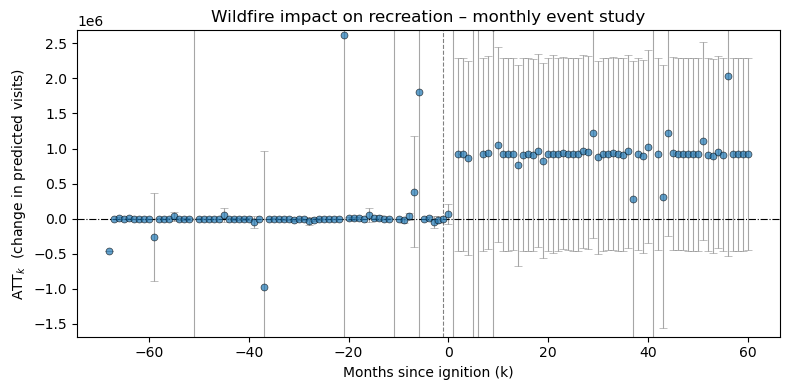

did_twfe_eventstudy_trimmed.png


In [11]:
# TWFE event-study, monthly scale based on Callaway Sant Anna and also Sun and Abraham
#   • unit FE  : by Incid_Name
#   • time FE  : calendar month (YYYY-MM)
#   1) reads the stacked panel
#   2) builds relative-month dummies and their treatment interactions
#   3) runs the TWFE regression with fire-level clustered SEs
#   4) writes out the month-wise ATT table
#   5) plots event-study plot 

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

ROOT     = Path("/Users/kyma3609/OneDrive - UCB-O365/Recreation_Fire/Modeling")
DATAFILE = ROOT / "stacked_mixedeffects_dataset_wildfires_co_fixed.csv"
CSVOUT   = ROOT / "monthly_ATT_twfe.csv"
FIGOUT   = ROOT / "did_twfe_eventstudy_trimmed.png"

df = pd.read_csv(DATAFILE, parse_dates=["eventDate"])

#################### variables###################
df["is_burned"] = df["treated"].astype(int)                   # 1 if pixel ever burns
df["rel_month"] = df["months_since_fire"].astype(int)         # event time k (…,-1,0,1,…)
df["post"]      = (df["rel_month"] > 0).astype(int)           # =1 in months after ignition
df["cal_m"]     = df["eventDate"].dt.to_period("M").astype(str)  # calendar month string


################### dummy matrix for every month ###################
def nice(k: int) -> str | None:
    if k == -1:
        return None
    return f"m{k}" if k >= 0 else f"m_neg{abs(k)}"

dum = pd.get_dummies(df["rel_month"])
dum = dum.rename(columns={c: nice(int(c)) for c in dum})
dum = dum.drop(columns=[c for c in dum.columns if c is None])       # drop baseline

# interaction terms: burned × month-k
treat_dum = dum.mul(df["is_burned"], axis=0).add_prefix("t_")

df = pd.concat([df, dum, treat_dum], axis=1)

month_cols   = dum.columns.tolist()        # plain dummies
tm_cols      = treat_dum.columns.tolist()  # treatment dummies


#################### TWFE model ###################
OUTCOME = "predicted_visits"
rhs      = ["is_burned*post"] + month_cols + tm_cols
formula  = f"{OUTCOME} ~ {' + '.join(rhs)} + C(Incid_Name) + C(cal_m)"

model = (smf.ols(formula, data=df)
           .fit(cov_type="cluster", cov_kwds={"groups": df["Incid_Name"]}))

print(model.summary())


#################### pull ATTk and 95-% CI ###################
def k_from(col: str) -> int:
    """Translate t_m… column names back to the integer month k."""
    base = col.replace("t_", "")
    if base.startswith("m_neg"):
        return -int(base.split("_neg")[1])
    elif base.startswith("m"):
        return int(base[1:])
    raise ValueError(f"unrecognised column {col}")

att = (pd.DataFrame({
            "rel_month": [k_from(c) for c in tm_cols],
            "ATT":       model.params[tm_cols],
            "SE":        model.bse[tm_cols]})
       .assign(lo=lambda d: d.ATT - 1.96*d.SE,
               hi=lambda d: d.ATT + 1.96*d.SE))

# add in the omitted baseline (effect = 0)
baseline = pd.DataFrame({"rel_month": [-1], "ATT": 0, "SE": np.nan,
                         "lo": 0, "hi": 0})
att = (pd.concat([att, baseline])
         .sort_values("rel_month")
         .reset_index(drop=True))

att.to_csv(CSVOUT, index=False)
print(f"→ wrote {CSVOUT.name}")

# figure, hide the outer 5 % of point estimates when scaling y-axis because outlieres zooming plot out way too much
lo, hi = att.ATT.quantile([0.05, 0.95])
focus  = att.query("@lo <= ATT <= @hi")

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(att.rel_month, att.ATT, yerr=1.96*att.SE,
            fmt="o", ecolor="grey", elinewidth=0.8,
            capsize=3, capthick=0.8, alpha=0.7,
            markeredgecolor="k", markeredgewidth=0.5, markersize=5)

ax.set_ylim(focus.lo.min(), focus.hi.max())
ax.axvline(-1, ls="--", lw=0.8, color="grey")   # baseline
ax.axhline(0,  ls="-.", lw=0.8, color="black")  # zero effect

ax.set_xlabel("Months since ignition (k)")
ax.set_ylabel("ATT$_k$  (change in predicted visits)")
ax.set_title("Wildfire impact on recreation – monthly event study")

fig.tight_layout()
fig.savefig(FIGOUT, dpi=300)
plt.show()
print(f"{FIGOUT.name}")
